In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [8]:
# 1. LOAD AND INSPECT DATA
df = pd.read_csv('sleep analysis data.csv')

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())


DATASET OVERVIEW

Dataset Shape: 384 rows × 25 columns

First 5 rows:
                        Timestamp  \
0  2025/04/29 8:16:33 pm GMT+5:30   
1  2025/04/29 8:21:49 pm GMT+5:30   
2  2025/04/30 9:53:56 am GMT+5:30   
3  2025/04/30 9:55:54 am GMT+5:30   
4  2025/04/30 9:56:00 am GMT+5:30   

  "This study is being conducted for academic research purposes. Your responses will be kept confidential and anonymous. Participation is voluntary. You may exit at any time."\n    \
0               I agree to participate in this study                                                                                                                                  
1               I agree to participate in this study                                                                                                                                  
2               I agree to participate in this study                                                                                                          

In [9]:
# Missing Values Analysis
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
print(missing)


MISSING VALUES ANALYSIS
                                               Column  Missing_Count  \
0                                           Timestamp              0   
1   "This study is being conducted for academic re...              0   
2                                                 Age              0   
3                                              Gender              0   
4                                          Department              0   
5                                    Living Condition              0   
6   How many hours of sleep do you usually get (at...              0   
7   How long does it take you to fall asleep after...              0   
8   During the past month, how often have you had ...              0   
9   During the past month, how often have you used...              0   
10    Is your sleep schedule consistent? \n (i.e.,...              0   
11  How often did you feel sleepy, tired, or have ...              0   
12  During the past month, were there a

In [10]:
# Simplify column names
df.columns = [
    'Timestamp', 'Consent', 'Age', 'Gender', 'Department', 'Living_Condition',
    'Sleep_Hours', 'Time_to_Fall_Asleep', 'Sleep_Troubles', 'Screen_Before_Sleep',
    'Sleep_Schedule_Consistent', 'Daytime_Sleepiness', 'External_Sleep_Disturbances',
    'Sleep_Quality_Rating', 'CGPA', 'PSS_Upset', 'PSS_Unable_Control',
    'PSS_Nervous_Stressed', 'PSS_Confident', 'PSS_Going_Your_Way',
    'PSS_Could_Not_Cope', 'PSS_Control_Irritations', 'PSS_On_Top_Things',
    'PSS_Angered', 'PSS_Difficulties_Piling'
]


In [11]:
# Clean Age (convert to numeric, handle outliers) Converted textual sleep duration responses into numeric values
df['Age_Numeric'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[df['Age_Numeric'] > 30, 'Age_Numeric'] = np.nan  # Remove outliers

In [12]:
# Extract numeric sleep hours
def extract_sleep_hours(value):
    if pd.isna(value):
        return np.nan
    value_str = str(value).lower()
    numbers = re.findall(r'\d+\.?\d*', value_str)
    if numbers:
        if len(numbers) >= 2:
            return (float(numbers[0]) + float(numbers[1])) / 2
        else:
            return float(numbers[0])
    return np.nan

df['Sleep_Hours_Numeric'] = df['Sleep_Hours'].apply(extract_sleep_hours)
df.loc[(df['Sleep_Hours_Numeric'] < 2) | (df['Sleep_Hours_Numeric'] > 12), 'Sleep_Hours_Numeric'] = np.nan

In [13]:
# Extract numeric CGPA
def extract_cgpa(value):
    if pd.isna(value):
        return np.nan
    value_str = str(value).lower()
    numbers = re.findall(r'\d+\.?\d*', value_str)
    if numbers:
        cgpa = float(numbers[0])
        if cgpa > 10:
            cgpa = cgpa / 10
        return cgpa
    return np.nan

df['CGPA_Numeric'] = df['CGPA'].apply(extract_cgpa)
df.loc[(df['CGPA_Numeric'] < 0) | (df['CGPA_Numeric'] > 10), 'CGPA_Numeric'] = np.nan

In [14]:
# 3. CALCULATE PSS-10 STRESS SCORE
pss_cols = ['PSS_Upset', 'PSS_Unable_Control', 'PSS_Nervous_Stressed', 'PSS_Confident',
            'PSS_Going_Your_Way', 'PSS_Could_Not_Cope', 'PSS_Control_Irritations',
            'PSS_On_Top_Things', 'PSS_Angered', 'PSS_Difficulties_Piling']

pss_mapping = {
    '0 - Never': 0,
    '1 - Almost Never': 1,
    '2 - Sometimes': 2,
    '3 - fairly Often': 3,
    '4 - Very Often': 4
}

In [15]:
# Convert to numeric scores
for col in pss_cols:
    df[col + '_Score'] = df[col].map(pss_mapping)

# Reverse scoring for items 4, 5, 7, 8
reverse_items = ['PSS_Confident_Score', 'PSS_Going_Your_Way_Score', 
                 'PSS_Control_Irritations_Score', 'PSS_On_Top_Things_Score']

for col in reverse_items:
    df[col + '_Reversed'] = 4 - df[col]


In [16]:
# Calculate total PSS-10 score
df['PSS_Total_Score'] = (
    df['PSS_Upset_Score'] + 
    df['PSS_Unable_Control_Score'] + 
    df['PSS_Nervous_Stressed_Score'] + 
    df['PSS_Confident_Score_Reversed'] +
    df['PSS_Going_Your_Way_Score_Reversed'] +
    df['PSS_Could_Not_Cope_Score'] +
    df['PSS_Control_Irritations_Score_Reversed'] +
    df['PSS_On_Top_Things_Score_Reversed'] +
    df['PSS_Angered_Score'] +
    df['PSS_Difficulties_Piling_Score']
)

In [17]:
# Categorize stress levels
def categorize_stress(score):
    if pd.isna(score):
        return np.nan
    if score <= 13:
        return 'Low Stress'
    elif score <= 26:
        return 'Moderate Stress'
    else:
        return 'High Stress'

df['Stress_Category'] = df['PSS_Total_Score'].apply(categorize_stress)

In [18]:

# Categorize sleep quality
def categorize_sleep_quality(rating):
    if pd.isna(rating):
        return np.nan
    rating_str = str(rating).lower()
    if 'very good' in rating_str:
        return 'Very Good'
    elif 'very poor' in rating_str:
        return 'Very Poor'
    elif 'poor' in rating_str:
        return 'Poor'
    elif 'good' in rating_str:
        return 'Good'
    return np.nan

df['Sleep_Quality_Category'] = df['Sleep_Quality_Rating'].apply(categorize_sleep_quality)

print("\n" + "="*80)
print("DATA PREPROCESSING COMPLETED")
print("="*80)


DATA PREPROCESSING COMPLETED


In [19]:
# 4. DESCRIPTIVE STATISTICS
print("\n" + "="*80)
print("CATEGORICAL VARIABLE DISTRIBUTIONS")
print("="*80)

categorical_vars = ['Gender', 'Department', 'Living_Condition', 'Time_to_Fall_Asleep',
                   'Screen_Before_Sleep', 'Sleep_Schedule_Consistent', 'Daytime_Sleepiness',
                   'Sleep_Quality_Category', 'Stress_Category']

for var in categorical_vars:
    print(f"\n{var}:")
    print(df[var].value_counts())
    print(f"Percentage distribution:")
    print((df[var].value_counts() / len(df) * 100).round(2))

print("\n" + "="*80)
print("NUMERIC VARIABLE STATISTICS")
print("="*80)

numeric_vars = ['Age_Numeric', 'Sleep_Hours_Numeric', 'CGPA_Numeric', 'PSS_Total_Score']
print(df[numeric_vars].describe())


CATEGORICAL VARIABLE DISTRIBUTIONS

Gender:
Gender
Male                 233
Female               148
Prefer not to say      3
Name: count, dtype: int64
Percentage distribution:
Gender
Male                 60.68
Female               38.54
Prefer not to say     0.78
Name: count, dtype: float64

Department:
Department
Technology/Engineering              309
Science(physics,chemistry,maths)     50
Arts/Humanities                      14
Commerce                              7
BSC Nursing                           1
Biotechnology                         1
Computer Application                  1
BCA Ai Ds                             1
Name: count, dtype: int64
Percentage distribution:
Department
Technology/Engineering              80.47
Science(physics,chemistry,maths)    13.02
Arts/Humanities                      3.65
Commerce                             1.82
BSC Nursing                          0.26
Biotechnology                        0.26
Computer Application                 0.26
BCA Ai

In [20]:
# 5. CORRELATION ANALYSIS
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

correlation_df = df[numeric_vars].dropna()
correlation_matrix = correlation_df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


CORRELATION ANALYSIS

Correlation Matrix:
                     Age_Numeric  Sleep_Hours_Numeric  CGPA_Numeric  \
Age_Numeric             1.000000             0.139363      0.009872   
Sleep_Hours_Numeric     0.139363             1.000000      0.004569   
CGPA_Numeric            0.009872             0.004569      1.000000   
PSS_Total_Score        -0.085638            -0.074773     -0.086099   

                     PSS_Total_Score  
Age_Numeric                -0.085638  
Sleep_Hours_Numeric        -0.074773  
CGPA_Numeric               -0.086099  
PSS_Total_Score             1.000000  


In [21]:
# 6. GROUP COMPARISONS
print("\n" + "="*80)
print("STATISTICAL SUMMARY BY SLEEP QUALITY")
print("="*80)
summary_by_quality = df.groupby('Sleep_Quality_Category').agg({
    'Sleep_Hours_Numeric': ['mean', 'std', 'count'],
    'PSS_Total_Score': ['mean', 'std'],
    'CGPA_Numeric': ['mean', 'std']
}).round(2)
print(summary_by_quality)

print("\n" + "="*80)
print("STATISTICAL SUMMARY BY STRESS CATEGORY")
print("="*80)
summary_by_stress = df.groupby('Stress_Category').agg({
    'Sleep_Hours_Numeric': ['mean', 'std', 'count'],
    'Sleep_Quality_Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
    'CGPA_Numeric': ['mean', 'std']
}).round(2)
print(summary_by_stress)

print("\n" + "="*80)
print("SUMMARY BY GENDER")
print("="*80)
summary_by_gender = df.groupby('Gender').agg({
    'Sleep_Hours_Numeric': 'mean',
    'PSS_Total_Score': 'mean',
    'CGPA_Numeric': 'mean'
}).round(2)
print(summary_by_gender)



STATISTICAL SUMMARY BY SLEEP QUALITY
                       Sleep_Hours_Numeric             PSS_Total_Score        \
                                      mean   std count            mean   std   
Sleep_Quality_Category                                                         
Good                                  6.40  1.21   203           19.71  4.93   
Poor                                  5.89  1.44   108           22.97  4.16   
Very Good                             6.97  1.18    35           16.86  6.52   
Very Poor                             5.39  2.24    35           24.23  6.58   

                       CGPA_Numeric        
                               mean   std  
Sleep_Quality_Category                     
Good                           7.82  1.06  
Poor                           7.45  1.22  
Very Good                      7.63  1.16  
Very Poor                      7.31  1.66  

STATISTICAL SUMMARY BY STRESS CATEGORY
                Sleep_Hours_Numeric             Sleep

Text(0.5, 1.0, 'Screen Usage Before Sleep')

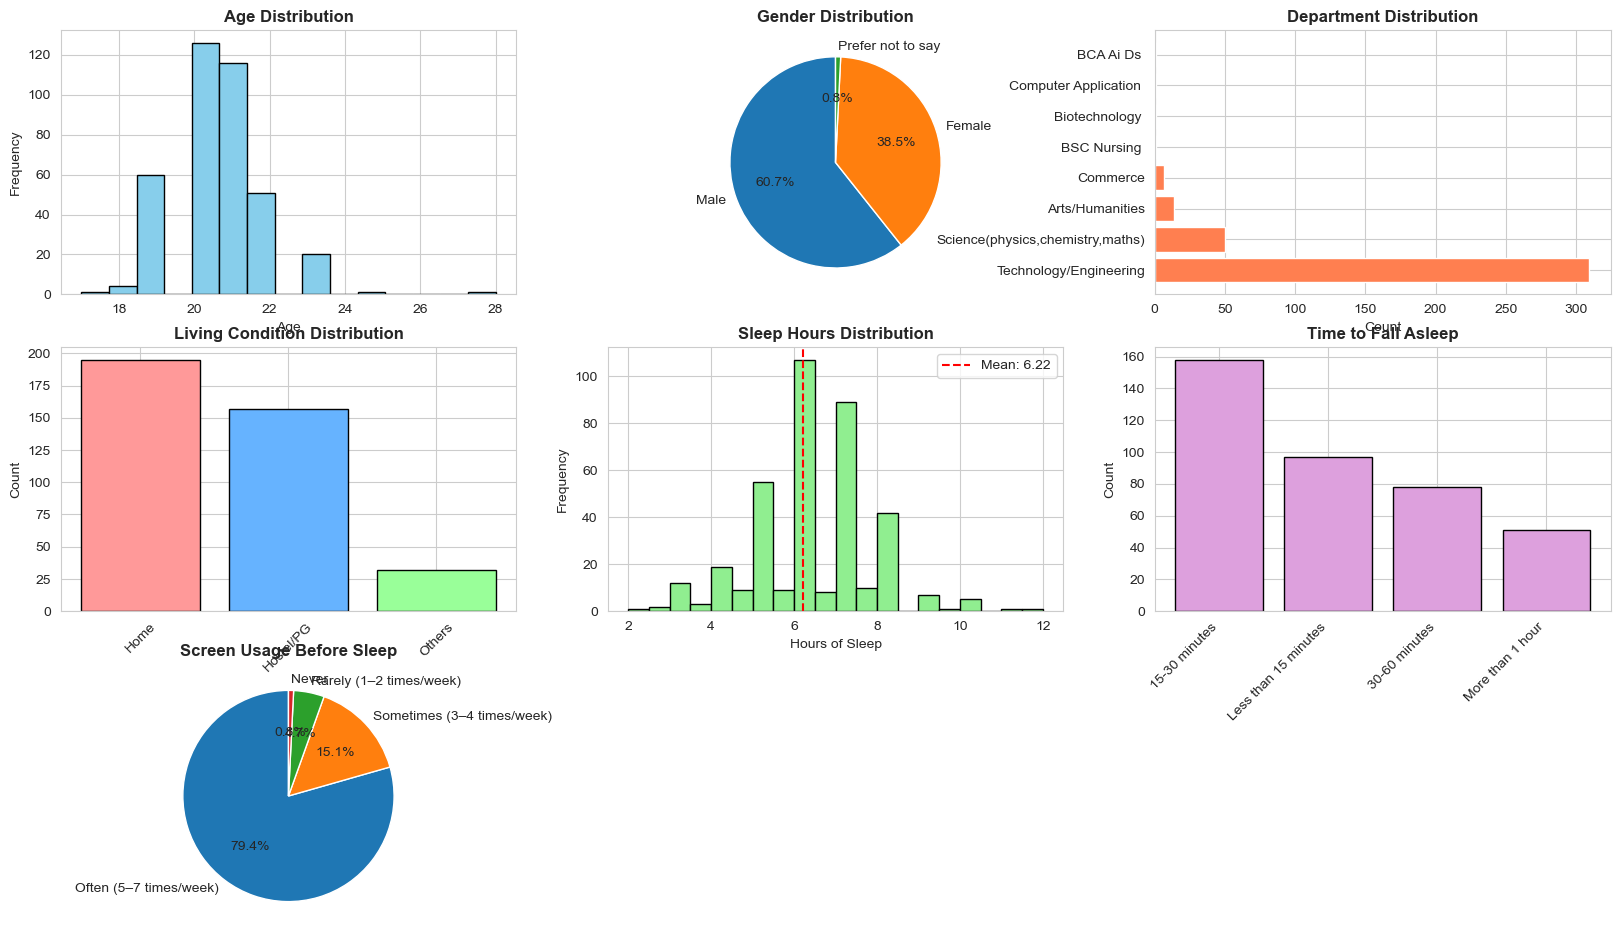

In [22]:
# 7. VISUALIZATIONS
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 24)

fig = plt.figure(figsize=(20, 24))

# 1. Age Distribution
plt.subplot(6, 3, 1)
plt.hist(df['Age_Numeric'].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 2. Gender Distribution
plt.subplot(6, 3, 2)
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution', fontsize=12, fontweight='bold')

# 3. Department Distribution
plt.subplot(6, 3, 3)
dept_counts = df['Department'].value_counts()
plt.barh(dept_counts.index, dept_counts.values, color='coral')
plt.title('Department Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Count')

# 4. Living Condition
plt.subplot(6, 3, 4)
living_counts = df['Living_Condition'].value_counts()
plt.bar(living_counts.index, living_counts.values, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
plt.title('Living Condition Distribution', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Count')

# 5. Sleep Hours Distribution
plt.subplot(6, 3, 5)
sleep_clean = df['Sleep_Hours_Numeric'].dropna()
plt.hist(sleep_clean, bins=20, color='lightgreen', edgecolor='black')
plt.title('Sleep Hours Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Hours of Sleep')
plt.ylabel('Frequency')
plt.axvline(sleep_clean.mean(), color='red', linestyle='--', 
            label=f'Mean: {sleep_clean.mean():.2f}')
plt.legend()

# 6. Time to Fall Asleep
plt.subplot(6, 3, 6)
time_counts = df['Time_to_Fall_Asleep'].value_counts()
plt.bar(range(len(time_counts)), time_counts.values, color='plum', edgecolor='black')
plt.xticks(range(len(time_counts)), time_counts.index, rotation=45, ha='right')
plt.title('Time to Fall Asleep', fontsize=12, fontweight='bold')
plt.ylabel('Count')

# 7. Screen Before Sleep
plt.subplot(6, 3, 7)
screen_counts = df['Screen_Before_Sleep'].value_counts()
plt.pie(screen_counts, labels=screen_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Screen Usage Before Sleep', fontsize=12, fontweight='bold')



Text(0, 0.5, 'Count')

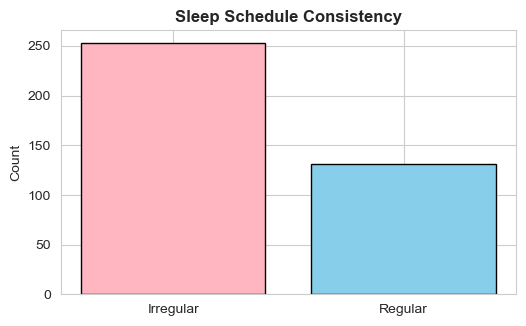

In [23]:
# 8. Sleep Schedule Consistency
plt.subplot(6, 3, 8)
schedule_counts = df['Sleep_Schedule_Consistent'].value_counts()
plt.bar(schedule_counts.index, schedule_counts.values, 
        color=['#FFB6C1', '#87CEEB'], edgecolor='black')
plt.title('Sleep Schedule Consistency', fontsize=12, fontweight='bold')
plt.ylabel('Count')

Text(0.5, 0, 'Count')

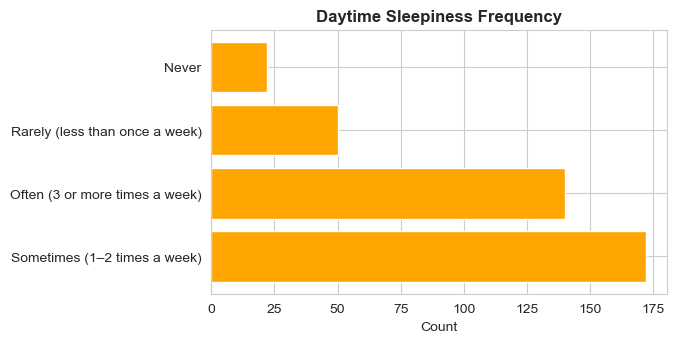

In [24]:
# 9. Daytime Sleepiness
plt.subplot(6, 3, 9)
sleepiness_counts = df['Daytime_Sleepiness'].value_counts()
plt.barh(sleepiness_counts.index, sleepiness_counts.values, color='orange')
plt.title('Daytime Sleepiness Frequency', fontsize=12, fontweight='bold')
plt.xlabel('Count')

Text(0, 0.5, 'Count')

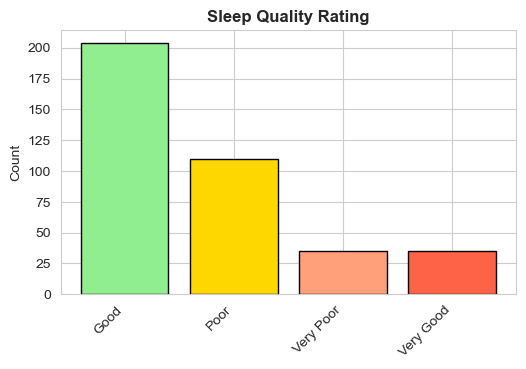

In [25]:
# 10. Sleep Quality Rating
plt.subplot(6, 3, 10)
quality_counts = df['Sleep_Quality_Category'].value_counts()
plt.bar(quality_counts.index, quality_counts.values, 
        color=['#90EE90', '#FFD700', '#FFA07A', '#FF6347'], edgecolor='black')
plt.title('Sleep Quality Rating', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

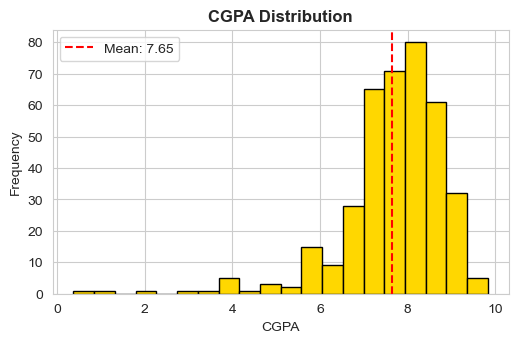

In [26]:
# 11. CGPA Distribution
plt.subplot(6, 3, 11)
cgpa_clean = df['CGPA_Numeric'].dropna()
plt.hist(cgpa_clean, bins=20, color='gold', edgecolor='black')
plt.title('CGPA Distribution', fontsize=12, fontweight='bold')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.axvline(cgpa_clean.mean(), color='red', linestyle='--', 
            label=f'Mean: {cgpa_clean.mean():.2f}')
plt.legend()

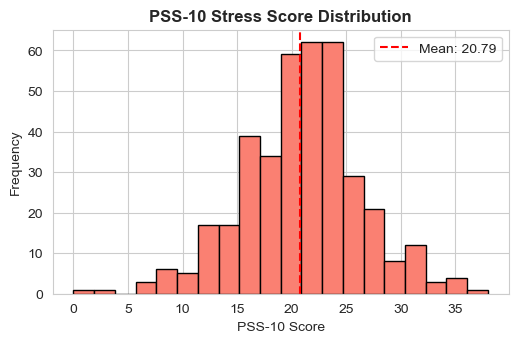

In [27]:

# 12. PSS-10 Score Distribution
plt.subplot(6, 3, 12)
plt.hist(df['PSS_Total_Score'], bins=20, color='salmon', edgecolor='black')
plt.title('PSS-10 Stress Score Distribution', fontsize=12, fontweight='bold')
plt.xlabel('PSS-10 Score')
plt.ylabel('Frequency')
plt.axvline(df['PSS_Total_Score'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["PSS_Total_Score"].mean():.2f}')
plt.legend()

Text(0.5, 1.0, 'Stress Level Categories')

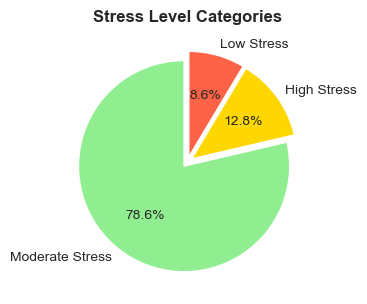

In [28]:
# 13. Stress Category Distribution
plt.subplot(6, 3, 13)
stress_counts = df['Stress_Category'].value_counts()
plt.pie(stress_counts, labels=stress_counts.index, autopct='%1.1f%%', 
        colors=['#90EE90', '#FFD700', '#FF6347'], explode=(0.05, 0.05, 0.05), startangle=90)
plt.title('Stress Level Categories', fontsize=12, fontweight='bold')

Text(0, 0.5, 'CGPA')

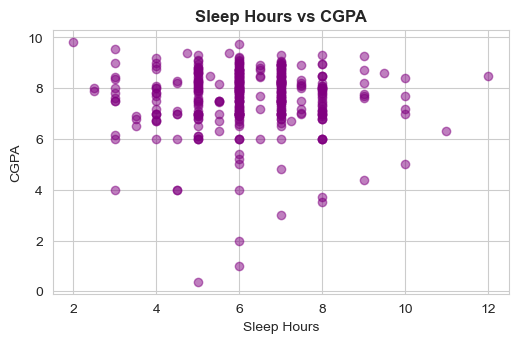

In [29]:
# 14. Sleep Hours vs CGPA
plt.subplot(6, 3, 14)
plt.scatter(df['Sleep_Hours_Numeric'], df['CGPA_Numeric'], alpha=0.5, color='purple')
plt.title('Sleep Hours vs CGPA', fontsize=12, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('CGPA')

Text(0, 0.5, 'PSS-10 Score')

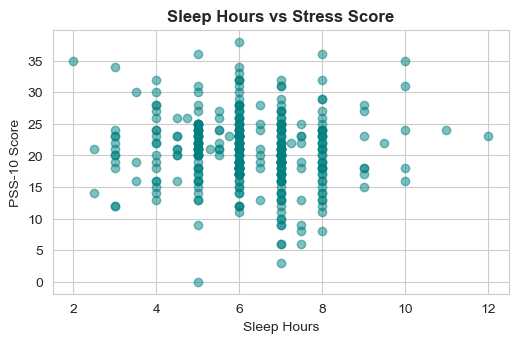

In [37]:
# 15. Sleep Hours vs Stress Score
plt.subplot(6, 3, 15)
plt.scatter(df['Sleep_Hours_Numeric'], df['PSS_Total_Score'], alpha=0.5, color='teal')
plt.title('Sleep Hours vs Stress Score', fontsize=12, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('PSS-10 Score')

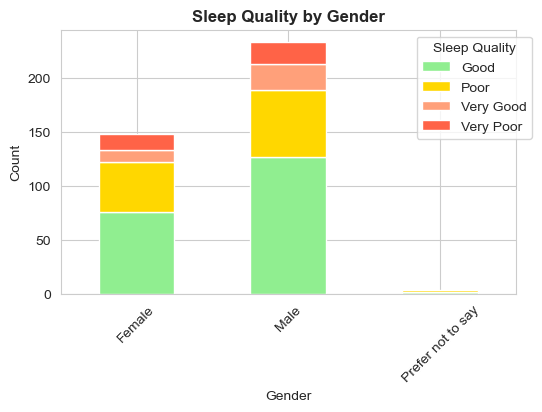

In [31]:
# 16. Sleep Quality by Gender
plt.subplot(6, 3, 16)
sleep_gender = pd.crosstab(df['Gender'], df['Sleep_Quality_Category'])
sleep_gender.plot(kind='bar', stacked=True, ax=plt.gca(), 
                  color=['#90EE90', '#FFD700', '#FFA07A', '#FF6347'])
plt.title('Sleep Quality by Gender', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1))

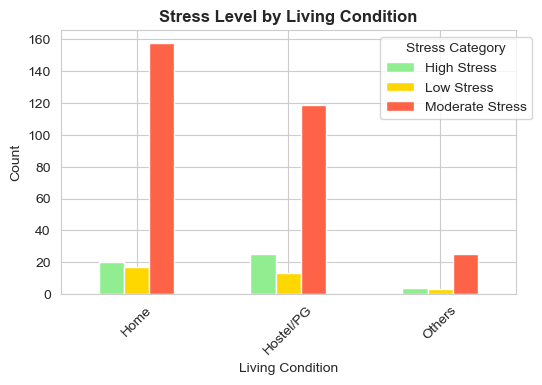

In [32]:
# 17. Stress Level by Living Condition
plt.subplot(6, 3, 17)
stress_living = pd.crosstab(df['Living_Condition'], df['Stress_Category'])
stress_living.plot(kind='bar', ax=plt.gca(), color=['#90EE90', '#FFD700', '#FF6347'])
plt.title('Stress Level by Living Condition', fontsize=12, fontweight='bold')
plt.xlabel('Living Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Stress Category', bbox_to_anchor=(1.05, 1))

In [33]:
# 18. Boxplot: Sleep Hours by Sleep Quality
plt.subplot(6, 3, 18)
df.boxplot(column='Sleep_Hours_Numeric', by='Sleep_Quality_Category', ax=plt.gca())
plt.title('Sleep Hours Distribution by Sleep Quality')
plt.suptitle('')
plt.xlabel('Sleep Quality')
plt.ylabel('Sleep Hours')
plt.tight_layout()
plt.savefig('sleep_analysis_eda_comprehensive.png', dpi=300, bbox_inches='tight')
print("\n✓ Comprehensive EDA visualization saved")
plt.close()


✓ Comprehensive EDA visualization saved


insight: Most variables show weak to moderate correlations, indicating that sleep behavior, stress, and academic performance are influenced by multiple interacting factors. 


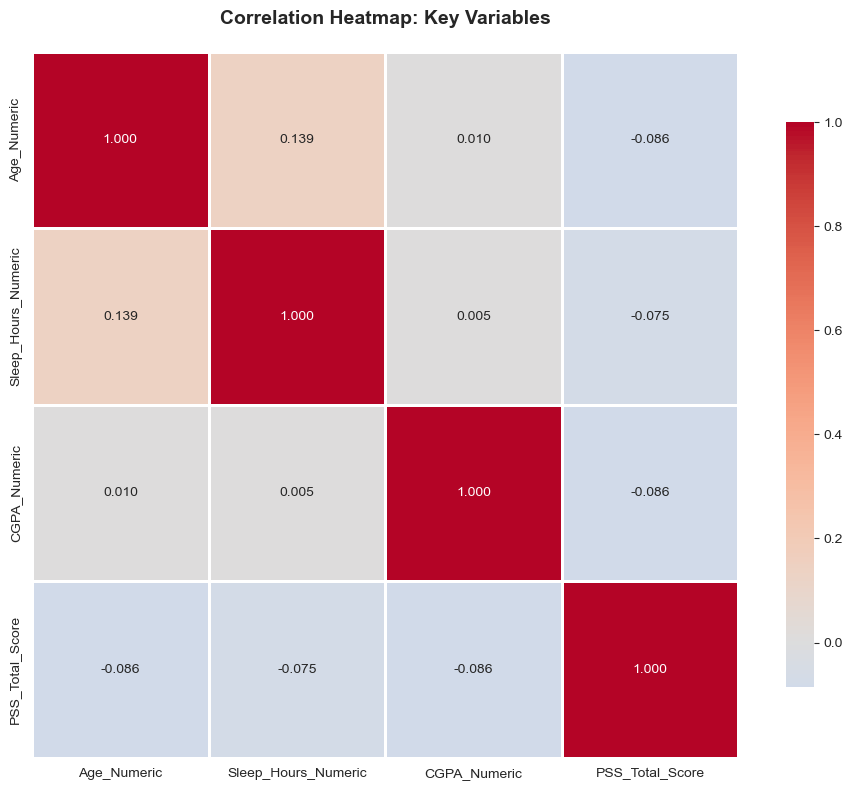

In [38]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Key Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
#plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
#print("✓ Correlation heatmap saved")
#plt.close()
print("insight: Most variables show weak to moderate correlations, indicating that sleep behavior, stress, and academic performance are influenced by multiple interacting factors. ")

In [36]:
# 8. SAVE CLEANED DATASET
df.to_csv('sleep_analysis_cleaned.csv', index=False)
print("\n Cleaned dataset saved as 'sleep_analysis_cleaned.csv'")

print("\n" + "="*80)
print("EDA COMPLETED SUCCESSFULLY")
print("="*80)
print("\nGenerated Files:")
print("1. sleep_analysis_eda_comprehensive.png - 18 visualization panels")
print("2. correlation_heatmap.png - Correlation analysis")
print("3. sleep_analysis_cleaned.csv - Cleaned dataset")


 Cleaned dataset saved as 'sleep_analysis_cleaned.csv'

EDA COMPLETED SUCCESSFULLY

Generated Files:
1. sleep_analysis_eda_comprehensive.png - 18 visualization panels
2. correlation_heatmap.png - Correlation analysis
3. sleep_analysis_cleaned.csv - Cleaned dataset
